In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [4]:
data = {
    'Loan_ID': ['LP001', 'LP002', 'LP003', 'LP004', 'LP005', 'LP006'],
    'Gender': ['Male', 'Female', np.nan, 'Male', 'Female', 'Male'],
    'Married': ['Yes', 'No', 'Yes', np.nan, 'Yes', 'No'],
    'Dependents': ['0', '1', '2', '3+', np.nan, '0'],
    'Education': ['Graduate', 'Graduate', 'Not Graduate', 'Graduate', 'Graduate', 'Not Graduate'],
    'Self_Employed': ['No', np.nan, 'Yes', 'No', 'No', 'Yes'],
    'ApplicantIncome': [5000, 3000, 4000, 6000, 3500, 4500],
    'CoapplicantIncome': [0, 1500, 1800, 0, 1200, 1000],
    'LoanAmount': [120, 100, np.nan, 150, 130, 110],
    'Loan_Amount_Term': [360, 360, np.nan, 180, 360, 360],
    'Credit_History': [1.0, 0.0, 1.0, np.nan, 1.0, 0.0],
    'Property_Area': ['Urban', 'Rural', 'Semiurban', 'Urban', 'Rural', 'Semiurban']
}

df = pd.DataFrame(data)

print("Initial Data Overview:")
print(df.info())
df.head()

Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            6 non-null      object 
 1   Gender             5 non-null      object 
 2   Married            5 non-null      object 
 3   Dependents         5 non-null      object 
 4   Education          6 non-null      object 
 5   Self_Employed      5 non-null      object 
 6   ApplicantIncome    6 non-null      int64  
 7   CoapplicantIncome  6 non-null      int64  
 8   LoanAmount         5 non-null      float64
 9   Loan_Amount_Term   5 non-null      float64
 10  Credit_History     5 non-null      float64
 11  Property_Area      6 non-null      object 
dtypes: float64(3), int64(2), object(7)
memory usage: 708.0+ bytes
None


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001,Male,Yes,0,Graduate,No,5000,0,120.0,360.0,1.0,Urban
1,LP002,Female,No,1,Graduate,NaN,3000,1500,100.0,360.0,0.0,Rural
2,LP003,NaN,Yes,2,Not Graduate,Yes,4000,1800,NaN,NaN,1.0,Semiurban
3,LP004,Male,NaN,3+,Graduate,No,6000,0,150.0,180.0,NaN,Urban
4,LP005,Female,Yes,NaN,Graduate,No,3500,1200,130.0,360.0,1.0,Rural


Loan_ID              0
Gender               1
Married              1
Dependents           1
Education            0
Self_Employed        1
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           1
Loan_Amount_Term     1
Credit_History       1
Property_Area        0
dtype: int64


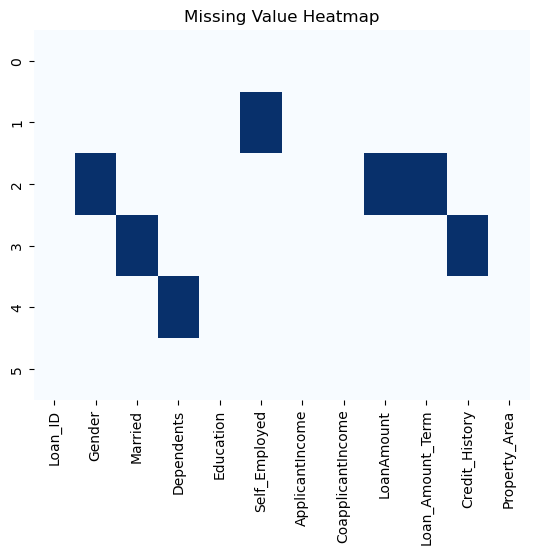

In [5]:
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Value Heatmap")
plt.show()

In [7]:
# Handling Missing Values
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

print("Missing values filled successfully!")
print(df.isnull().sum())

Missing values filled successfully!
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [8]:
initial_rows = len(df)

df.drop_duplicates(inplace=True)

print("Duplicates Removed:", initial_rows - len(df))

Duplicates Removed: 0


In [9]:
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

In [10]:
for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']:
    df[col] = df[col].str.strip().str.capitalize()

In [11]:
min_max_scaler = MinMaxScaler()

scale_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

df[scale_cols] = min_max_scaler.fit_transform(df[scale_cols])

standard_scaler = StandardScaler()

df[['Credit_History']] = standard_scaler.fit_transform(df[['Credit_History']])

In [12]:
print("Cleaned Data Summary:")
print(df.info())

print(df.head())

Cleaned Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            6 non-null      object 
 1   Gender             6 non-null      object 
 2   Married            6 non-null      object 
 3   Dependents         6 non-null      int32  
 4   Education          6 non-null      object 
 5   Self_Employed      6 non-null      object 
 6   ApplicantIncome    6 non-null      float64
 7   CoapplicantIncome  6 non-null      float64
 8   LoanAmount         6 non-null      float64
 9   Loan_Amount_Term   6 non-null      float64
 10  Credit_History     6 non-null      float64
 11  Property_Area      6 non-null      object 
dtypes: float64(5), int32(1), object(6)
memory usage: 684.0+ bytes
None
  Loan_ID  Gender Married  Dependents     Education Self_Employed  \
0   LP001    Male     Yes           0      Graduate            N